In [2]:
%load_ext autoreload
%autoreload 2

In [158]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time
from shapely.geometry import Polygon, Point

import geopandas as gpd

# from src.text_processing_functions import *
from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

In [4]:
#Select one report 
# all_reports = pd.read_csv(DATA_OUT_LLMS+'labelled_reports_response_llm_levels_haz_types_subtypes_impacts_geocoding.csv')
file_path = DATA_IN_JSONS +'all_ifrc_reports_info_unnested_with_text.json'#'nathaz_ifrc_reports_info_processed.json'

# Open and read the JSON file
with open(file_path, 'r') as json_file:
    ifrc_reports_processed = json.load(json_file)
all_reports = pd.DataFrame(ifrc_reports_processed)
all_reports = all_reports.rename({"location" : "country"}, axis=1)
# all_reports = all_reports.rename({"disasterTypeReclassified" : "hazardType"}, axis=1)

# Debug the code 

In [5]:
df_llm = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925.csv', encoding='utf-8')

In [6]:
df = df_llm
similarity_th=0.2
split_lowest_levels=True
print_info=False
save_path=False
res_savename=False
polygon_source="geoBoundaries"

In [7]:
df_geo = deepcopy(df)

if "country_kw" in df_geo.columns : 
    col_to_list = ["location", "country", "country_kw"]
    df_type = "llm"
else : 
    col_to_list = ["location", "country"]
    df_type = "labelled"

for col in col_to_list : 
    df_geo[col] = df_geo[col].apply(
        lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) and x.strip().startswith("[") else ([x] if pd.notna(x) else None)
    )

# Open Polygons
gpd_files = open_admin_gpd(ADMIN_PATH, polygon_source)

In [195]:
# Collect unique locations and associated countries
start = time.time()
unique_locations_countries = defaultdict(set)
for _, row in df_geo.iterrows():
    countries = row["country"]
    # ensure it's iterable (list), even if single country
    if not isinstance(countries, (list, set, tuple)):
        countries = [countries]
    
    locations = row["location"]
    if not locations:  
        for c in countries:
            unique_locations_countries[c].update([c])

    else : 
        for loc in row["location"]:
            unique_locations_countries[loc].update(countries)
unique_locations_countries = dict(unique_locations_countries)
end = time.time()
time_open = (end - start) / 60
print(f"Numer of unique locations : {len(unique_locations_countries)}")
print(f"Time to identify all locations {time_open}mins")

Numer of unique locations : 2453
Time to identify all locations 0.0015248735745747885mins


In [197]:
# Run nominatim for each loc 
start = time.time()
# nom_loc_dict = {}
for loc in unique_locations_countries : 
    if loc not in nom_loc_dict:
        countries = unique_locations_countries[loc]
        nom_loc_dict[loc] = find_best_nomin(loc, countries, similarity_th, print_info=False)
end = time.time()
time_open = (end - start) / 60
print(f"Time to nominatim all locations {time_open}mins")

Time to nominatim all locations 39.06132289171219mins


In [199]:
start = time.time()
max_workers = min(10, (os.cpu_count() or 1) + 2)
df_geo_individual_locs = run_parallel_geocode(nom_loc_dict, unique_locations_countries, gpd_files, print_info=False, max_workers=max_workers)
end = time.time()
time_open = (end - start) / 60
print(f"Time to geocode all locations {time_open}mins")

Error processing Ledia: cannot access local variable 'df_gpd' where it is not associated with a value
Time to geocode all locations 0.844638987382253mins


In [ ]:
start = time.time()
max_workers = min(32, (os.cpu_count() or 1) * 2 + 4)
df_geo_output = run_parallel_associate(df_geo, df_geo_individual_locs, gpd_files, split_lowest_levels=split_lowest_levels, polygon_source=polygon_source, max_workers=max_workers)
end = time.time()
time_open = (end - start) / 60
print(f"Time to gather locations per rows {time_open}mins")

Error processing row 52: 'float' object cannot be interpreted as an integer
Error processing row 215: 'float' object cannot be interpreted as an integer
Error processing row 235: 'float' object cannot be interpreted as an integer
Error processing row 337: 'float' object cannot be interpreted as an integer
Error processing row 350: TopologyException: side location conflict at 44.89045807338217 41.208341419007546. This can occur if the input geometry is invalid.
Error processing row 352: 'float' object cannot be interpreted as an integer
Error processing row 353: TopologyException: side location conflict at 44.89045807338217 41.208341419007546. This can occur if the input geometry is invalid.
Error processing row 398: bad allocation
Error processing row 549: TopologyException: side location conflict at -58.365602475200681 -34.049669547612361. This can occur if the input geometry is invalid.
Error processing row 552: TopologyException: side location conflict at -58.365754123878162 -34.049

In [203]:
len(df_geo_output)

7

In [135]:
# Save to final df 
res_savename = "post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
save_path = DATA_PATH
save_df = df_geo_output.copy()

save_df = delistify_cols(save_df)
save_gdf = gpd.GeoDataFrame(save_df, geometry='geometry')
save_gdf = save_gdf.set_crs("EPSG:4326", allow_override=True)
try:
    suffix = "_geo_split_lowest" if split_lowest_levels else "_geo"

    #Save gpkg
    gpkg_path = save_path + f"{res_savename}{suffix}.gpkg"
    if not atomic_gpkg_save(save_gdf, gpkg_path):
        raise Exception(f"[GeoPackage Save Error] Failed to save GeoPackage to {gpkg_path}")
    # if os.path.exists(gpkg_path):
    #     os.remove(gpkg_path)
    # save_gdf.to_file(gpkg_path,
    #                 layer="multipolygons", driver="GPKG")

    # #Save shp
    # shp_path = f"{save_path}{res_savename}{suffix}.shp"
    # if os.path.exists(shp_path):
    #     os.remove(shp_path)
    # save_gdf.to_file(shp_path, driver="ESRI Shapefile")
except Exception as e:
    print(f"[GeoPackage Save Error] {e}")

In [134]:
save_path + f"{res_savename}{suffix}.gpkg"

'c:/Users/lhasbini/ownCloud/Documents/Thèse/Conférences_Discussions/2024_Como_Compound Events Training/data/post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925_geo_split_lowest.gpkg'

In [132]:
gpkg_path

NameError: name 'gpkg_path' is not defined

In [ ]:
type(df_geo_output["locationPolygon"].iloc[0])

list

In [127]:
type(save_df["locationPolygon"].iloc[0])

str

# Convert location to polygons

In [98]:
#Post process files 
df_labelled = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_labelled_reports_impacts_all.csv', encoding='utf-8')
# df_llm = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_llm_response_impact_labelled_reports_test_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct.csv', encoding='utf-8')
# df_llm = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_llm_response_impact_labelled_reports_test_multiprompt_16rep_meta-llama_llama-4-scout-17b-16e-instruct.csv', encoding='utf-8')
# df_llm = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct.csv', encoding='utf-8')
df_llm = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925.csv', encoding='utf-8')

# df_labelled = pd.read_csv(DATA_LABELLED + 'labelled_reports_impact_laura_18-08-25.csv', encoding='utf-8')


In [5]:
## Parallelized version 
similarity_th=0.2
similarity_polygon = 0.6
print_info=False
save_path= False
split_lowest_levels = True

#For the llm version 
save_path = False#DATA_PATH + 'results_proc/'
# res_savename = 'post_processed_llm_response_impact_labelled_reports_test_multiprompt_16rep_meta-llama_llama-4-scout-17b-16e-instruct'
# res_savename = "post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct"

# df_llm_geo_split = geocode_df_to_polygon_v2_parrallel(df_llm, similarity_th=0.2, split_lowest_levels=split_lowest_levels, 
#                                          print_info=print_info, save_path=save_path, res_savename=False, 
#                                          polygon_source="geoBoundaries")

# # #Without splitting over highest admin levels 
# split_lowest_levels = False
# df_llm_geo = geocode_df_to_polygon_v2_parrallel(df_llm, similarity_th=0.2, split_lowest_levels=split_lowest_levels, 
#                                                 print_info=print_info, save_path=save_path, res_savename=res_savename, 
#                                                 polygon_source="geoBoundaries")

In [101]:
df_llm["location"]

0                                                      []
1       ['Alta Verapaz', 'Izabal', 'Quiché', 'Huehuete...
2       ['Sula Valley', 'Copán', 'Choluteca', 'Comayag...
3                                                      []
4                                                      []
                              ...                        
3432                                        ['Viti Levu']
3433    ['Central', 'Western', 'Northern', 'North', 'E...
3434    ['Central', 'Western', 'Northern divisions', '...
3435      ['Central', 'Western', 'Northern', 'Viti Levu']
3436    ['Central', 'Western', 'Northern divisions', '...
Name: location, Length: 3437, dtype: object

In [99]:
df_llm_geo_split = geocode_df_to_polygon_by_unique_loc(df_llm, similarity_th=0.2, split_lowest_levels=split_lowest_levels, 
                                         print_info=print_info, save_path=save_path, res_savename=False, 
                                         polygon_source="geoBoundaries")

Numer of unique locations : 2407
Time to identify all locations 0.002107540766398112mins


MemoryError: 

In [7]:
df_llm_geo_split

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,impactUnitOrig,unit_type,geometry,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,impactValueApprox
0,Human Deaths,306.0,NaN,NaN,exact,people,['The monsoon season caused306 fatalities and5...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa (KP), Sindh, ...",['The monsoon season caused306 fatalities and5...,...,people,other,MULTIPOLYGON (((68.07540854914413 23.785859876...,ADM_1,0,0,"[Balochistan, Khyber Pakhtunkhwa, Sindh, Punja...","[Balochistan, Khyber Pakhtunkhwa, Sindh, Punja...",PAK,NaN
1,Injured People,584.0,NaN,NaN,exact,people,['The monsoon season caused306 fatalities and5...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa (KP), Sindh, ...",['The monsoon season caused306 fatalities and5...,...,people,other,MULTIPOLYGON (((68.07540854914413 23.785859876...,ADM_1,0,0,"[Balochistan, Khyber Pakhtunkhwa, Sindh, Punjab]","[Balochistan, Khyber Pakhtunkhwa, Sindh, Punjab]",PAK,NaN
2,Displaced People,9500.0,NaN,NaN,exact,people,"['Sindh experienced acute urban flooding, part...",[Pakistan],"[Sindh, Badin, Dadu, Jacobabad]","['Sindh experienced acute urban flooding, part...",...,people,other,MULTIPOLYGON (((68.07540854914413 23.785859876...,ADM_1,0,0,"[Sindh, Badin, Dadu, Jacobabad]","[Sindh, Badin, Dadu, Jacobabad]",PAK,NaN
3,Displaced People,NaN,NaN,NaN,exact,NaN,"['Sindh experienced acute urban flooding, part...",[Pakistan],"[Sindh, Badin, Dadu, Jacobabad]","['Sindh experienced acute urban flooding, part...",...,people,other,MULTIPOLYGON (((68.76228041384567 24.276847688...,ADM_2,0,0,"[Badin, Dadu, Jacobabad]","[Badin, Dadu, Jacobabad]",PAK,NaN
4,Affected People,109602.0,NaN,NaN,exact,people,['Emergency declarations were issued in eight ...,[Pakistan],[Balochistan],['Emergency declarations were issued in eight ...,...,people,other,MULTIPOLYGON (((66.46168163554722 25.491209542...,ADM_1,0,0,[Balochistan],[Balochistan],PAK,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,Displaced People,23000.0,NaN,NaN,exact,people,"['more than23,000 people, mainly from smaller ...",[Malaysia],"[Johor, Kelantan, Pahang, Perak, Terengganu, M...","['more than23,000 people, mainly from smaller ...",...,people,other,MULTIPOLYGON (((103.52498142958444 1.408651121...,ADM_1,0,0,"[Johor, Kelantan, Pahang, Perak, Terengganu, M...","[Johor, Kelantan, Pahang, Perak, Terengganu, M...",MYS,NaN
330,Human Deaths,1.0,NaN,NaN,exact,people,['national agency for d isaster administration...,[Malaysia],[Johor],['national agency for d isaster administration...,...,fatality,other,MULTIPOLYGON (((103.52371526488173 1.406584030...,ADM_1,0,0,[Johor],[Johor],MYS,NaN
331,Affected People,15000.0,NaN,NaN,exact,people,['overall o bjective to support mrcs in ensur ...,[Malaysia],"[Johor, Pahang, Terengganu]",['overall o bjective to support mrcs in ensur ...,...,people,other,MULTIPOLYGON (((103.52371526488173 1.406623782...,ADM_1,0,0,"[Johor, Pahang, Terengganu]","[Johor, Pahang, Terengganu]",MYS,NaN
332,Displaced People,8000.0,NaN,NaN,exact,people,['national agency for d isaster administration...,[Malaysia],[Johor],['national agency for d isaster administration...,...,evacuees,other,MULTIPOLYGON (((103.52371526488173 1.406584030...,ADM_1,0,0,[Johor],[Johor],MYS,NaN


In [36]:
df_llm_geo_split_old_geoboundaries[["impactSubtype", "impactValue", "location", "locationLowestAdmin", 
                                    "geocoding_country_flag", "geocoding_osm_flag", "locationOsm", "locationPolygon"]]

,impactSubtype,impactValue,location,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon
0,Human Deaths,306.0,"[Balochistan, Khyber Pakhtunkhwa (KP), Sindh, ...",ADM_1,0,0,"[Balochistan, Khyber Pakhtunkhwa, Sindh, Punja...","[Balochistan, Khyber Pakhtunkhwa, Sindh, Punja..."
1,Injured People,584.0,"[Balochistan, Khyber Pakhtunkhwa (KP), Sindh, ...",ADM_1,0,0,"[Balochistan, Khyber Pakhtunkhwa, Sindh, Punjab]","[Balochistan, Khyber Pakhtunkhwa, Sindh, Punjab]"
2,Displaced People,9500.0,"[Sindh, Badin, Dadu, Jacobabad]",ADM_1,0,0,"[Sindh, Badin, Dadu, Jacobabad]","[Sindh, Badin, Dadu, Jacobabad]"
3,Displaced People,NaN,"[Sindh, Badin, Dadu, Jacobabad]",ADM_2,0,0,"[Badin, Dadu, Jacobabad]","[Badin, Dadu, Jacobabad]"
4,Affected People,109602.0,[Balochistan],ADM_1,0,0,[Balochistan],[Balochistan]
5,Homeless People,15000.0,"[Balochistan, Sindh, Khyber Pakhtunkhwa (KP), ...",ADM_1,0,0,"[Balochistan, Sindh, Khyber Pakhtunkhwa, Punjab]","[Balochistan, Sindh, Khyber Pakhtunkhwa, Punjab]"
6,Residential Buildings,20653.0,"[Balochistan, Sindh, Punjab, Khyber Pakhtunkhwa]",ADM_1,0,0,"[Balochistan, Sindh, Punjab, Khyber Pakhtunkhwa]","[Balochistan, Sindh, Punjab, Khyber Pakhtunkhwa]"
7,"Water, Sanitation, and Hygiene Infrastructure",NaN,"[Sohbatpur district, Balochistan]",ADM_0,1,0,[Pakistan],[Pakistan]
8,Healthcare Infrastructure,NaN,"[Balochistan, Khyber Pakhtunkhwa (KP), Sindh, ...",ADM_1,0,0,"[Balochistan, Khyber Pakhtunkhwa, Sindh, Punja...","[Balochistan, Khyber Pakhtunkhwa, Sindh, Punja..."
9,Human Health and Wellbeing,NaN,"[Sindh, Balochistan, Khyber Pakhtunkhwa (KP)]",ADM_1,0,0,"[Sindh, Balochistan, Khyber Pakhtunkhwa]","[Sindh, Balochistan, Khyber Pakhtunkhwa]"


In [5]:
similarity_th=0.2
similarity_polygon = 0.6
print_info=False
save_path=DATA_PATH #False
#res_savename=False 
split_lowest_levels = True

#For the llm version 
save_path = DATA_PATH + 'results_proc/'
# res_savename = 'post_processed_llm_response_impact_labelled_reports_test_multiprompt_16rep_meta-llama_llama-4-scout-17b-16e-instruct'
res_savename = "post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct"

df_llm_geo_split = geocode_df_to_polygon(df_llm, similarity_th=0.2, split_lowest_levels=split_lowest_levels, print_info=print_info, save_path=save_path, res_savename=res_savename)

# #Without splitting over highest admin levels 
# split_lowest_levels = False
# df_llm_geo = geocode_df_to_polygon(df_llm, similarity_th=0.2, split_lowest_levels=split_lowest_levels, print_info=print_info, save_path=save_path, res_savename=res_savename)

c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\geocoding.py:558: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)


[Atomic save] failed: [WinError 3] Le chemin d’accès spécifié est introuvable
[GeoPackage Save Error] [GeoPackage Save Error] Failed to save GeoPackage to c:/Users/lhasbini/ownCloud/Documents/Thèse/Conférences_Discussions/2024_Como_Compound Events Training/data/results_proc/post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct_geo_split_lowest.gpkg


In [15]:
##### For the labelled version 

## Splitting the highest levels
split_lowest_levels = True 
# save_path = DATA_PATH + 'results_proc/'
# res_savename = 'post_processed_labelled_reports_impacts_all'
save_path = DATA_LABELLED
res_savename = 'labelled_reports_impact_laura_18-08-25'
# df_labelled_geo_split = geocode_df_to_polygon(df_labelled, similarity_th=0.2, split_lowest_levels=split_lowest_levels, print_info=print_info, save_path=save_path, res_savename=res_savename)

## Withou splitting the highest levels 
split_lowest_levels = False
df_labelled_geo = geocode_df_to_polygon(df_labelled, similarity_th=0.2, split_lowest_levels=split_lowest_levels, print_info=print_info, save_path=save_path, res_savename=res_savename)

c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\geocoding.py:558: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)
c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\geocoding.py:558: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo_output = pd.concat([df_geo_output, df_row_append], ignore_index=True)


In [45]:
df_labelled_geo_split = geocode_df_to_polygon_by_unique_loc(df_labelled, similarity_th=0.2, split_lowest_levels=split_lowest_levels, 
                                         print_info=print_info, save_path=save_path, res_savename=False, 
                                         polygon_source="geoBoundaries")

Numer of unique locations : 276
Time to identify all locations 0.00016667842864990235mins
Time to nominatim all locations 4.860189898808797mins
Found Admin 3, location : Islami Bank Bangladesh Ltd , country :  Bangladesh  adm_lev : 3
[geocode_from_nomin_output_optimized] 'str' object cannot be interpreted as an integer. Falling back to country level.
level_name : ADMIN_3, target_name : Lama
[get_polygon] Error: 'ADMIN_3'
[geocode_from_nomin_output_optimized] 'str' object cannot be interpreted as an integer. Falling back to country level.
[geocode_from_nomin_output_optimized] 'str' object cannot be interpreted as an integer. Falling back to country level.
[geocode_from_nomin_output_optimized] 'str' object cannot be interpreted as an integer. Falling back to country level.
[geocode_from_nomin_output_optimized] 'str' object cannot be interpreted as an integer. Falling back to country level.
[geocode_from_nomin_output_optimized] 'str' object cannot be interpreted as an integer. Falling bac

Geocoding locations:   0%|          | 0/276 [00:00<?, ?it/s]

[geocode_from_nomin_output_optimized] 'str' object cannot be interpreted as an integer. Falling back to country level.
[geocode_from_nomin_output_optimized] 'str' object cannot be interpreted as an integer. Falling back to country level.


Geocoding locations:   0%|          | 1/276 [00:00<04:04,  1.13it/s]

Found Admin 3, location : Chattogram-Coxs Bazar Highway , country :  Bangladesh  adm_lev : 3
level_name : ADMIN_3, target_name : Dohazari
[get_polygon] Error: 'ADMIN_3'
[geocode_from_nomin_output_optimized] 'str' object cannot be interpreted as an integer. Falling back to country level.
[geocode_from_nomin_output_optimized] 'str' object cannot be interpreted as an integer. Falling back to country level.
[geocode_from_nomin_output_optimized] 'str' object cannot be interpreted as an integer. Falling back to country level.


...

Time to geocode all locations 0.14244000116984049mins


Merging locations:   0%|          | 0/408 [00:00<?, ?it/s]

Error processing row 0: 'float' object cannot be interpreted as an integer
Error processing row 1: 'float' object cannot be interpreted as an integer


Merging locations: 100%|██████████| 408/408 [01:37<00:00,  4.19it/s]


Error processing row 36: 'float' object cannot be interpreted as an integer
Error processing row 37: 'float' object cannot be interpreted as an integer
Error processing row 38: 'float' object cannot be interpreted as an integer
Error processing row 39: 'float' object cannot be interpreted as an integer
Error processing row 40: 'float' object cannot be interpreted as an integer
Error processing row 41: 'float' object cannot be interpreted as an integer
Error processing row 42: 'float' object cannot be interpreted as an integer
Error processing row 43: 'float' object cannot be interpreted as an integer
Error processing row 44: 'float' object cannot be interpreted as an integer
Error processing row 46: 'float' object cannot be interpreted as an integer
Error processing row 47: 'float' object cannot be interpreted as an integer
Error processing row 48: 'float' object cannot be interpreted as an integer
Error processing row 49: 'float' object cannot be interpreted as an integer
Error proces

## Quality of the geocoding

- For each appealCode : 
    - Number of unique locations found 
    - Over this locations, split between the ones geocoded and the level at which they have been geocoded (ADM_0/ADM_1/ADM_2)

In [29]:
df_llm_geo.head()

,impactSubtype,impactValue,impactUnit,impactValuePrecision,country,location,startYear,startMonth,startDay,endYear,...,unit_type,gaul0_code,gaul1_code,gaul2_code,locationPolygon,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationGaul
0,Residential Buildings,205368.00,homes,exact,[Bangladesh],[19 affected districts],2020.0,5.0,20.0,NaN,...,other,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]
1,Residential Buildings,55767.00,homes,exact,[Bangladesh],[19 affected districts],2020.0,5.0,20.0,NaN,...,other,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]
2,Crop Production and Forestry,320.37,km**2 of crop production and forestry,exact,[Bangladesh],[19 affected districts],2020.0,5.0,20.0,NaN,...,km**2,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]
3,"Water, Sanitation, and Hygiene Infrastructure",18235.00,"water, sanitation and hygiene facilities",exact,[Bangladesh],[19 affected districts],2020.0,5.0,20.0,NaN,...,other,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]
4,Other Transportation Infrastructure,440.00,km of roads,exact,[Bangladesh],[19 affected districts],2020.0,5.0,20.0,NaN,...,km,[229.0],[None],[None],MULTIPOLYGON (((89.06421959700003 21.822088934...,ADM_0,1,0,[Bangladesh],[Bangladesh]


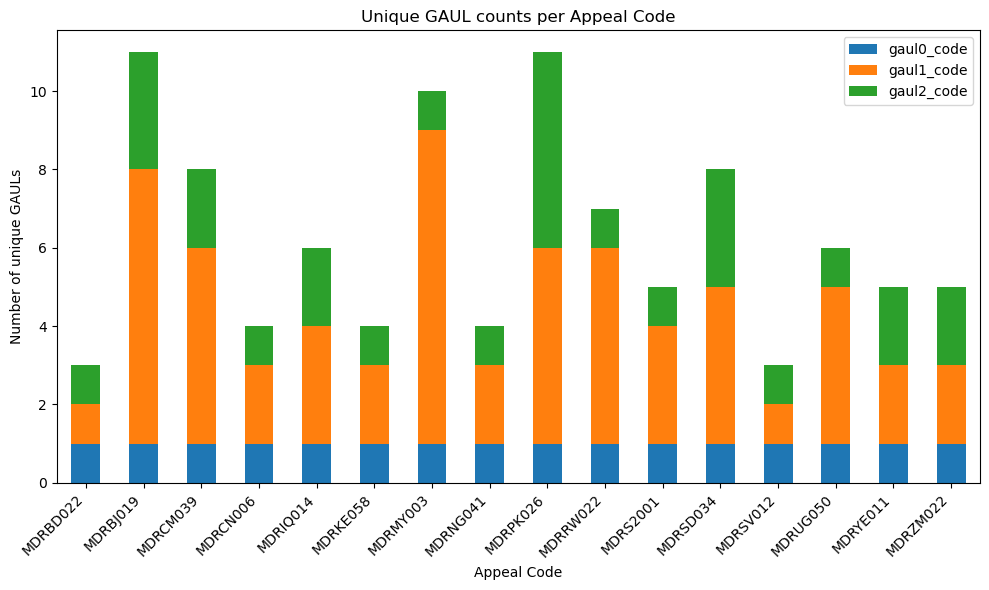

In [31]:
def count_unique_lists(series):
    all_elements = set()
    for lst in series:
        if isinstance(lst, list):
            all_elements.update(lst)
    return len(all_elements)

# Prepare the data
plot_data = df_llm_geo.groupby('appealCode').agg({
    'gaul0_code': count_unique_lists,
    'gaul1_code': count_unique_lists,
    'gaul2_code': count_unique_lists
})

# Plot
ax = plot_data.plot(kind='bar', stacked=True, figsize=(10,6))
ax.set_ylabel("Number of unique GAULs")
ax.set_xlabel("Appeal Code")
ax.set_title("Unique GAUL counts per Appeal Code")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

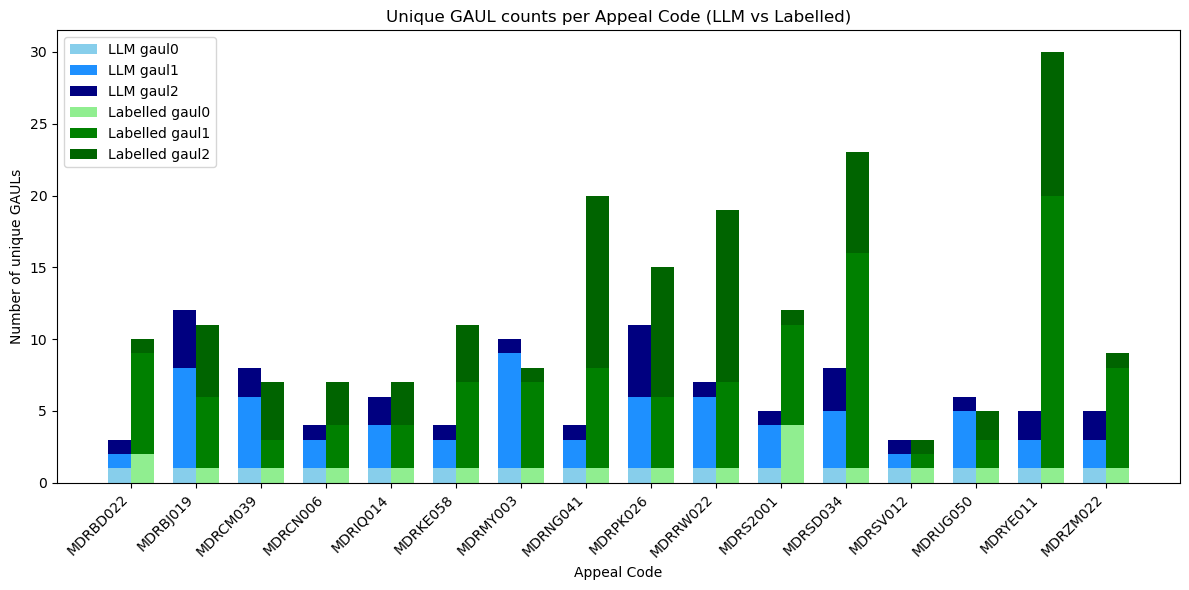

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# Function to count unique elements in lists per group
def count_unique_lists(series):
    all_elements = set()
    for lst in series:
        if isinstance(lst, list):
            all_elements.update(lst)
    return len(all_elements)

# Aggregate data for both datasets
plot_data_llm = df_llm_geo.groupby('appealCode').agg({
    'gaul0_code': count_unique_lists,
    'gaul1_code': count_unique_lists,
    'gaul2_code': count_unique_lists
})

plot_data_labelled = df_labelled_geo.groupby('appealCode').agg({
    'gaul0_code': count_unique_lists,
    'gaul1_code': count_unique_lists,
    'gaul2_code': count_unique_lists
})

# Make sure both have the same appealCodes in the same order
all_codes = sorted(set(plot_data_llm.index) | set(plot_data_labelled.index))
plot_data_llm = plot_data_llm.reindex(all_codes, fill_value=0)
plot_data_labelled = plot_data_labelled.reindex(all_codes, fill_value=0)

# Set bar positions
x = np.arange(len(all_codes))
width = 0.35  # width of each bar

# Plot
fig, ax = plt.subplots(figsize=(12,6))

# LLM bars
ax.bar(x - width/2, plot_data_llm['gaul0_code'], width, label='LLM gaul0', color='skyblue', bottom=0)
ax.bar(x - width/2, plot_data_llm['gaul1_code'], width, label='LLM gaul1', color='dodgerblue', bottom=plot_data_llm['gaul0_code'])
bottom_llm = plot_data_llm['gaul0_code'] + plot_data_llm['gaul1_code']
ax.bar(x - width/2, plot_data_llm['gaul2_code'], width, label='LLM gaul2', color='navy', bottom=bottom_llm)

# Labelled bars
ax.bar(x + width/2, plot_data_labelled['gaul0_code'], width, label='Labelled gaul0', color='lightgreen', bottom=0)
ax.bar(x + width/2, plot_data_labelled['gaul1_code'], width, label='Labelled gaul1', color='green', bottom=plot_data_labelled['gaul0_code'])
bottom_labelled = plot_data_labelled['gaul0_code'] + plot_data_labelled['gaul1_code']
ax.bar(x + width/2, plot_data_labelled['gaul2_code'], width, label='Labelled gaul2', color='darkgreen', bottom=bottom_labelled)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(all_codes, rotation=45, ha='right')
ax.set_ylabel("Number of unique GAULs")
ax.set_xlabel("Appeal Code")
ax.set_title("Unique GAUL counts per Appeal Code (LLM vs Labelled)")
ax.legend(loc='upper left')
plt.tight_layout()
fig.savefig(DATA_FIGURE+'counts_unique_loc_admin_appealCode_llm-labelled.png', dpi=300, bbox_inches='tight', transparent=True)

In [48]:
counts_labelled

locationLowestAdmin,ADM_0,ADM_1,ADM_2
appealCode,,,
MDRBD022,1,1,0
MDRBJ019,1,3,2
MDRCM039,1,0,0
MDRCN006,1,2,2
MDRIQ014,1,0,2
MDRKE058,1,4,1
MDRMY003,0,6,0
MDRNG041,1,5,3
MDRPK026,1,6,6


In [49]:
df_llm_exploded = df_llm_geo_split.explode("locationPolygon")
df_llm_exploded["locationPolygon"] = (
    df_llm_exploded["locationPolygon"]
    .apply(lambda x: x if isinstance(x, str) else str(x))
)
counts_llm = (
    df_llm_exploded
    .groupby(["appealCode", "locationLowestAdmin"])["locationPolygon"]
    .nunique()
    .unstack(fill_value=0)              # wide format: columns = ADM_0, ADM_1, ADM_2
    .reindex(columns=["ADM_0", "ADM_1", "ADM_2"], fill_value=0)  # ensure order
)

df_labelled_exploded = df_labelled_geo_split.explode("locationPolygon")
df_labelled_exploded["locationPolygon"] = (
    df_labelled_exploded["locationPolygon"]
    .apply(lambda x: x if isinstance(x, str) else str(x))
)
counts_labelled = (
    df_labelled_exploded
    .groupby(["appealCode", "locationLowestAdmin"])["locationPolygon"]
    .nunique()
    .unstack(fill_value=0)              # wide format: columns = ADM_0, ADM_1, ADM_2
    .reindex(columns=["ADM_0", "ADM_1", "ADM_2"], fill_value=0)  # ensure order
)

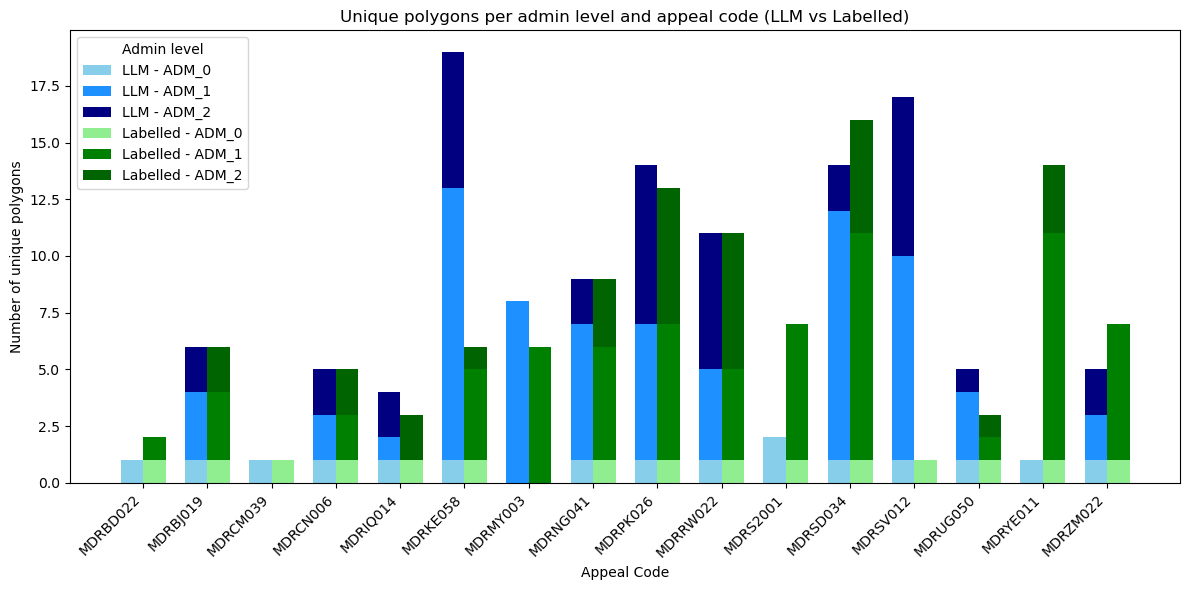

In [50]:
# Build shared index of all appealCodes
all_appeal_codes = counts_llm.index.union(counts_labelled.index)

# Reindex both DataFrames to have the same index (fill missing with 0)
counts_llm = counts_llm.reindex(all_appeal_codes, fill_value=0)
counts_labelled = counts_labelled.reindex(all_appeal_codes, fill_value=0)

### PLOT
levels = ["ADM_0", "ADM_1", "ADM_2"]
colors_llm = ["skyblue", "dodgerblue", "navy"]
colors_labelled = ["lightgreen", "green", "darkgreen"]

x = np.arange(len(all_appeal_codes))  # one bar per appealCode
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))

# LLM bars
bottom = np.zeros(len(all_appeal_codes))
for level, color in zip(levels, colors_llm):
    ax.bar(x - width/2, counts_llm[level], width, label=f"LLM - {level}", color=color, bottom=bottom)
    bottom += counts_llm[level]

# Labelled bars
bottom = np.zeros(len(all_appeal_codes))
for level, color in zip(levels, colors_labelled):
    ax.bar(x + width/2, counts_labelled[level], width, label=f"Labelled - {level}", color=color, bottom=bottom)
    bottom += counts_labelled[level]

# Labels
ax.set_xticks(x)
ax.set_xticklabels(all_appeal_codes, rotation=45, ha="right")
ax.set_ylabel("Number of unique polygons")
ax.set_xlabel("Appeal Code")
ax.set_title("Unique polygons per admin level and appeal code (LLM vs Labelled)")
ax.legend(title="Admin level", loc="upper left")

plt.tight_layout()
plt.show()


In [70]:
df_labelled_exploded.loc[df_labelled_exploded["appealCode"]=="MDRUG050"]["locationPolygon"].unique()

array(['Uganda', 'Eastern Region', 'Bungokho'], dtype=object)

In [71]:
df_llm_exploded.loc[df_llm_exploded["appealCode"]=="MDRUG050"]["locationPolygon"].unique()

array(['Uganda', 'Central Region', 'Eastern Region', 'Western Region',
       'Bungokho'], dtype=object)

In [77]:
df_llm_geo_split.loc[df_llm_geo_split["appealCode"]=="MDRMY003"]#.iloc[2]["location"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,impactUnitOrig,unit_type,geometry,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,impactValueApprox
329,Displaced People,23000.0,NaN,NaN,exact,people,"['more than23,000 people, mainly from smaller ...",[Malaysia],"[Johor, Kelantan, Pahang, Perak, Terengganu, M...","['more than23,000 people, mainly from smaller ...",...,people,other,MULTIPOLYGON (((103.52498142958444 1.408651121...,ADM_1,0,0,"[Johor, Kelantan, Pahang, Perak, Terengganu, M...","[Johor, Kelantan, Pahang, Perak, Terengganu, M...",MYS,NaN
330,Human Deaths,1.0,NaN,NaN,exact,people,['national agency for d isaster administration...,[Malaysia],[Johor],['national agency for d isaster administration...,...,fatality,other,MULTIPOLYGON (((103.52371526488173 1.406584030...,ADM_1,0,0,[Johor],[Johor],MYS,NaN
331,Affected People,15000.0,NaN,NaN,exact,people,['overall o bjective to support mrcs in ensur ...,[Malaysia],"[Johor, Pahang, Terengganu]",['overall o bjective to support mrcs in ensur ...,...,people,other,MULTIPOLYGON (((103.52371526488173 1.406623782...,ADM_1,0,0,"[Johor, Pahang, Terengganu]","[Johor, Pahang, Terengganu]",MYS,NaN
332,Displaced People,8000.0,NaN,NaN,exact,people,['national agency for d isaster administration...,[Malaysia],[Johor],['national agency for d isaster administration...,...,evacuees,other,MULTIPOLYGON (((103.52371526488173 1.406584030...,ADM_1,0,0,[Johor],[Johor],MYS,NaN
333,Human Health and Wellbeing,NaN,NaN,NaN,NaN,unknown,['families that stayed in evacuation centres f...,[Malaysia],"[Johor, Pahang, Terengganu]","['the floods forced more than23,000 people acr...",...,NaN,other,MULTIPOLYGON (((103.52371526488173 1.406623782...,ADM_1,0,0,"[Johor, Pahang, Terengganu]","[Johor, Pahang, Terengganu]",MYS,NaN


In [76]:
df_labelled_geo_split.loc[df_labelled_geo_split["appealCode"]=="MDRMY003"]#.iloc[2]["location"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,impactsAnnotation,country,location,...,impactUnitOrig,unit_type,geometry,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,impactValueApprox
65,2017-11-21,Displaced People,23000.0,people,approx,23000.0,NaN,"['More than 23,000 people, mainly from smaller...",[Malaysia],"[Johor, Kelantan, Pahang, Perak, Terengganu, S...",...,people,other,MULTIPOLYGON (((103.52498142958444 1.408651121...,ADM_1,0,0,"[Johor, Kelantan, Pahang, Perak, Terengganu, S...","[Johor, Kelantan, Pahang, Perak, Terengganu, S...",MYS,NaN
66,2017-11-21,Displaced People,8000.0,people,approx,8000.0,NaN,['National Agency for Disaster Administration ...,[Malaysia],[Johor],...,people,other,MULTIPOLYGON (((103.52371526488173 1.406584030...,ADM_1,0,0,[Johor],[Johor],MYS,NaN
67,2017-11-21,Human Deaths,1.0,people,exact,NaN,NaN,['National Agency for Disaster Administration ...,[Malaysia],[Johor],...,people,other,MULTIPOLYGON (((103.52371526488173 1.406584030...,ADM_1,0,0,[Johor],[Johor],MYS,NaN


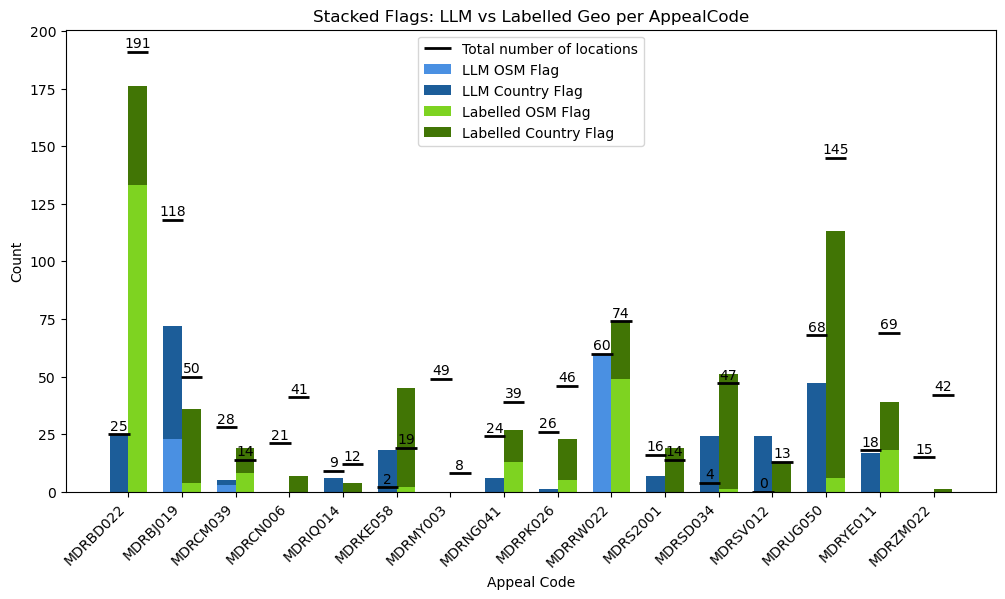

In [84]:
# Compute number of locations per row
for df in [df_llm_geo_split, df_labelled_geo]:
    df['num_locations'] = df['location'].apply(len)

# Group by appealCode
grouped_llm = df_llm_geo_split.groupby('appealCode').agg({
    'num_locations': 'sum',
    'geocoding_osm_flag': 'sum',
    'geocoding_country_flag': 'sum'
}).reset_index()

grouped_labelled = df_labelled_geo.groupby('appealCode').agg({
    'num_locations': 'sum',
    'geocoding_osm_flag': 'sum',
    'geocoding_country_flag': 'sum'
}).reset_index()

# Set bar width and positions
bar_width = 0.35
x = np.arange(len(grouped_llm['appealCode']))

fig, ax = plt.subplots(figsize=(12,6))

# Colors
llm_colors = ['#4A90E2', '#1C5D99']       # Light blue, dark blue
labelled_colors = ['#7ED321', '#417505']  # Light green, dark green

# LLM bars
ax.bar(x - bar_width/2, grouped_llm['geocoding_osm_flag'], bar_width, color=llm_colors[0], label='LLM OSM Flag')
ax.bar(x - bar_width/2, grouped_llm['geocoding_country_flag'], bar_width, 
       bottom=grouped_llm['geocoding_osm_flag'], color=llm_colors[1], label='LLM Country Flag')

# Labelled bars
ax.bar(x + bar_width/2, grouped_labelled['geocoding_osm_flag'], bar_width, color=labelled_colors[0], label='Labelled OSM Flag')
ax.bar(x + bar_width/2, grouped_labelled['geocoding_country_flag'], bar_width, 
       bottom=grouped_labelled['geocoding_osm_flag'], color=labelled_colors[1], label='Labelled Country Flag')

# Plot total reports as lines
for i in range(len(x)):
    ax.hlines(y=grouped_llm['num_locations'][i], xmin=i - bar_width/2 - 0.2, xmax=i - bar_width/2 + 0.2, 
              color='black', lw=2, label='Total number of locations' if i==0 else "")
    ax.text(i - bar_width/2, grouped_llm['num_locations'][i] + 0.5, str(grouped_llm['num_locations'][i]), 
            ha='center', va='bottom', fontsize=10)
    
    ax.hlines(y=grouped_labelled['num_locations'][i], xmin=i + bar_width/2 - 0.2, xmax=i + bar_width/2 + 0.2, 
              color='black', lw=2)
    ax.text(i + bar_width/2, grouped_labelled['num_locations'][i] + 0.5, str(grouped_labelled['num_locations'][i]), 
            ha='center', va='bottom', fontsize=10)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(grouped_llm['appealCode'], rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_xlabel('Appeal Code')
ax.set_title('Stacked Flags: LLM vs Labelled Geo per AppealCode')
ax.legend()
fig.savefig(DATA_FIGURE+'counts_flags_appealCode_llm-labelled.png', dpi=300, bbox_inches='tight', transparent=True)
